**Key hypothesis:** Sorting pairs low-n runs (narrow FWHM) with low target quantiles,
and high-n runs with high target quantiles — structured, directional gradient signal per quantile.

---

### Empirical Finding (2000-run ρ test)

We tested ρ(n_sorted, per_quantile_loss) across μ values with 2000 runs per test:

| μ | ρ(n, loss) | grad_μ | Signal? |
|---|-----------|--------|---------|
| 20 | −0.16 | −0.50 | ✅ Strong, correct direction |
| 30 | −0.09 | −0.11 | ✅ Weaker, still correct |
| 40 | +0.02 | +0.01 | ❌ Noise |
| 50 | +0.02 | +0.03 | ❌ At truth, no signal |
| 60 | +0.01 | +0.03 | ❌ Noise |

**Conclusion:** The sorted quantile matching works. The REINFORCE gradient is real and
points in the right direction when μ is below the truth. The signal decays as μ approaches
the truth — it pulls the optimizer out of the low-μ regime but fades near the truth, where
the W₁ loss landscape takes over.

**Implication for optimization:** A run starting at μ=20 would get strong signal to ~33,
weak signal to ~40, then rely on the decreasing W₁ loss to converge the remaining ~10 units.


## Imports & Setup


In [1]:
import math, time
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

torch.set_default_dtype(torch.float32)

# Model definitions from src/
from src.fitting import (
    FREQ_MIN, FREQ_MAX, UNIFORM_DENSITY, WIDTH_MAX, WIDTH_EPS, FIT_ETA,
    _width, _raw_from_width, _lorentz_cdf, _normal_cdf,
    log_pdf, nll, fwhm_from_theta, fit_profile,
    run_one_ple_scan, voigt_fwhm
)
from src.samplers import signal_detunings, build_photons, draw_fixed_noise
from src.losses import wasserstein_loss, per_run_wasserstein_sorted

print('All imports from src/')


from dataclasses import dataclass


@dataclass
class MCParams:
    nbar: float
    sigma: float = 6.0
    lambda_: float = 2.0


@dataclass
class SimParams:
    gamma: float = 20.0
    sigma_n: float = 6.0
    lambda_: float = 2.0


All imports from src/


## Parameters


In [2]:
@dataclass
class SimParams:
    '''Fixed parameters for the forward MC simulation.'''
    gamma: float = 20.0       # Lorentzian HWHM (MHz) - fixed
    sigma_n: float = 6.0      # physical std of per-scan photon counts
    lambda_: float = 2.0      # mean background counts per run


# True mean photon count to recover
NBAR_TRUE = 50.0

# Runs per batch
N_RUNS = 80
N_TARGET_RUNS = 200

params = SimParams()
print(f'Target: nbar_true = {NBAR_TRUE}, gamma = {params.gamma}, sigma_n = {params.sigma_n}')


Target: nbar_true = 50.0, gamma = 20.0, sigma_n = 6.0


## Fitting - Truncation-aware Pseudo-Voigt + Background (MLE)

From the 07 notebook, inlined for consistency.


In [3]:
# Model functions imported from src/fitting.py above.
# This cell kept as a reminder that everything is now in src/.
print('Fitting functions from src/')


Fitting functions from src/


## Per-Run Wasserstein Loss (Sorted Quantile Match)

Sort **both** the B simulated FWHMs and the target, then match quantile-to-quantile:

$$\mathrm{loss}_i = |f_{(i)} - y_{(i)}| \quad\text{for } i = 1, \dots, B$$

This is the **per-quantile decomposition of the 1D Wasserstein-1 distance**:
the average of these losses is exactly W1, and each component measures
how far off is our simulation at that quantile.

**Key insight:** Sorting pairs low-n runs (narrow FWHM) with low target quantiles,
and high-n runs with high target quantiles — creating structured, directional signal.


In [4]:
# per_run_wasserstein_sorted imported from src/losses.py
print('Per-run loss from src/')


Per-run loss from src/


## Log-Probability of Rounded Normal


In [5]:
# per_run_wasserstein_sorted imported from src/losses.py
print('Per-run loss from src/')


Per-run loss from src/


## Generate Target Data


Generating target data: 200 runs at nbar_true=50.0...


Target FWHM: mean=68.1, median=63.8, std=29.2, N=200


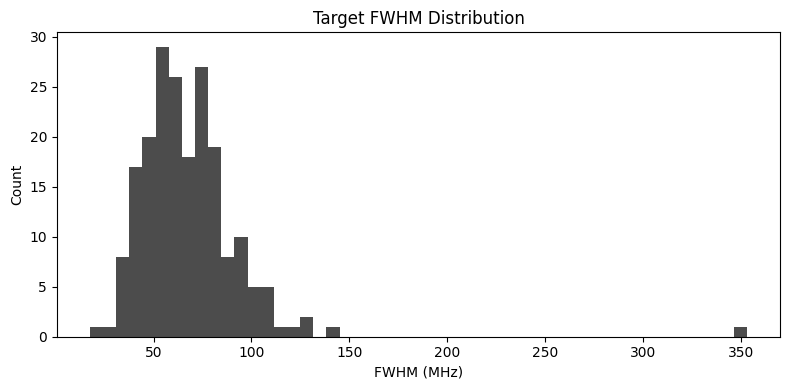

In [6]:
print(f'Generating target data: {N_TARGET_RUNS} runs at nbar_true={NBAR_TRUE}...')
rng_target = np.random.default_rng(2026)
target_fwhms = []

for _ in range(N_TARGET_RUNS):
    n = max(round(NBAR_TRUE + params.sigma_n * rng_target.standard_normal()), 0)
    fwhm = run_one_ple_scan(n, params.gamma, params.lambda_, rng_target)
    target_fwhms.append(fwhm)

target_fwhms = torch.tensor(target_fwhms, dtype=torch.float32)
print(f'Target FWHM: mean={target_fwhms.mean().item():.1f}, median={target_fwhms.median().item():.1f}, '
      f'std={target_fwhms.std().item():.1f}, N={len(target_fwhms)}')

# Quick histogram diagnostic
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(target_fwhms.numpy(), bins=50, alpha=0.7, color='k')
ax.set_xlabel('FWHM (MHz)')
ax.set_ylabel('Count')
ax.set_title('Target FWHM Distribution')
plt.tight_layout()
plt.show()


## Per-Run REINFORCE Optimization

**The sorted quantile match:**
- Run B scans -> B FWHMs, each with its n_i
- Sort the FWHMs, match quantile-to-quantile with target
- Each quantile i gets loss = |f_{(i)} - y_{(i)}|
- Carry n_i through the sort: n_{(i)} is the n that produced f_{(i)}

**The REINFORCE gradient:**

$$\nabla_\mu = \frac{1}{B} \sum_{i=1}^B (|f_{(i)} - y_{(i)}| - b) \cdot \frac{n_{(i)} - \mu}{\sigma^2}$$

where the score function for a Normal distribution is $(n_{(i)} - \mu) / \sigma^2$.

**Track:** correlation rho(n_{(i)}, |f_{(i)} - y_{(i)}|) — the per-quantile correlation.


In [7]:
# ==== Optimization hyperparams ====
MU_INIT = 20.0              # far from truth
SIGMA_PROP = 12.0           # fixed proposal std
LR_MU = 5.0                 # learning rate for mu
N_ITER = 50                 # optimization iterations
BASELINE_ALPHA = 0.05       # EMA smoothing
CLIP_GRAD = 10.0            # gradient norm clipping

# ==== Optimizable params ====
mu = torch.tensor([MU_INIT], requires_grad=True, dtype=torch.float32)
sigma_val = SIGMA_PROP

baseline = 0.0

# ==== Diagnostics storage ====
history = []

print('Starting per-run REINFORCE with sorted quantile matching')
print(f'  mu_init = {MU_INIT}, sigma_prop = {SIGMA_PROP}')
print(f'  N_RUNS = {N_RUNS}, N_ITER = {N_ITER}, LR_MU = {LR_MU}')
print()

for step in range(N_ITER):
    rng = np.random.default_rng(42 + step)
    mu_val = mu.item()

    # ---- 1. Per-run: draw n_i, run PLE scan, get FWHM_i ----
    ns = []
    fwhms = []
    for _ in range(N_RUNS):
        n = max(round(mu_val + sigma_val * rng.standard_normal()), 0)
        ns.append(n)
        fwhm = run_one_ple_scan(n, params.gamma, params.lambda_, rng)
        fwhms.append(fwhm)

    ns_t = torch.tensor(ns, dtype=torch.float32)
    fwhms_t = torch.tensor(fwhms, dtype=torch.float32)

    # ---- 2. Sorted quantile matching ----
    per_quantile_loss, sort_idx, mean_loss = per_run_wasserstein_sorted(fwhms_t, target_fwhms)
    ns_sorted = ns_t[sort_idx]

    # ---- 3. Diagnostic: correlation n_sorted vs per_quantile_loss ----
    rho = 0.0
    if per_quantile_loss.std() > 0.01 and ns_sorted.std() > 0.01:
        rho = np.corrcoef(ns_sorted.detach().numpy(), per_quantile_loss.detach().numpy())[0, 1]

    # ---- 4. REINFORCE gradient on mu ----
    advantages = per_quantile_loss - baseline
    scores = (ns_sorted - mu_val) / sigma_val**2
    raw_grad_mu = (advantages.detach() * scores).mean()
    grad_mu = torch.clamp(raw_grad_mu, -CLIP_GRAD, CLIP_GRAD)

    # ---- 5. Update mu ----
    with torch.no_grad():
        mu -= LR_MU * grad_mu
        mu.clamp_(1.0, 200.0)

    # ---- 6. Update EMA baseline ----
    baseline = (1.0 - BASELINE_ALPHA) * baseline + BASELINE_ALPHA * mean_loss

    # ---- 7. Log ----
    history.append({
        'step': step,
        'mu': mu.item(),
        'sigma': sigma_val,
        'mean_loss': mean_loss,
        'baseline': baseline,
        'mean_n': np.mean(ns),
        'rho_n_loss': rho,
        'grad_mu': grad_mu.item(),
        'mean_advantage': advantages.mean().item(),
        'std_advantage': advantages.std().item(),
        'std_n': np.std(ns),
        'mean_fwhm': np.mean(fwhms),
        'std_fwhm': np.std(fwhms),
        'n_degenerate': sum(1 for f in fwhms if abs(f - 2*params.gamma) < 0.1),
    })

    if step % 10 == 0 or step == 0 or step == N_ITER - 1:
        h = history[-1]
        print(f"Step {step:3d}: mu={h['mu']:6.1f} sigma={h['sigma']:5.1f} | {h['mean_loss']:.4f} bl={h['baseline']:.4f} | {h['grad_mu']:+.3f} | nbar={h['mean_n']:5.1f} rho={h['rho_n_loss']:+.3f} | FWHM={h['mean_fwhm']:5.1f}+-{h['std_fwhm']:4.1f} | deg={h['n_degenerate']}")

print()
print('Done.')

Starting per-run REINFORCE with sorted quantile matching
  mu_init = 20.0, sigma_prop = 12.0
  N_RUNS = 80, N_ITER = 50, LR_MU = 5.0



Step   0: mu=  22.7 sigma= 12.0 | 27.0182 bl=1.3509 | -0.539 | nbar= 19.7 rho=-0.145 | FWHM= 62.7+-55.0 | deg=3


Step  10: mu=  41.3 sigma= 12.0 | 18.9070 bl=9.9113 | -0.458 | nbar= 37.7 rho=-0.175 | FWHM= 64.4+-36.2 | deg=0


Step  20: mu=  37.0 sigma= 12.0 | 23.3247 bl=14.0633 | -0.307 | nbar= 34.1 rho=-0.068 | FWHM= 70.5+-42.5 | deg=1


Step  30: mu=  45.1 sigma= 12.0 | 11.6826 bl=16.2856 | -0.001 | nbar= 42.4 rho=-0.113 | FWHM= 57.3+-19.1 | deg=0


Step  40: mu=  42.0 sigma= 12.0 | 15.6563 bl=17.8866 | -0.049 | nbar= 43.0 rho=-0.028 | FWHM= 62.2+-21.3 | deg=0


Step  49: mu=  45.5 sigma= 12.0 | 24.6709 bl=19.3947 | +0.303 | nbar= 48.5 rho=+0.082 | FWHM= 71.5+-47.3 | deg=0

Done.


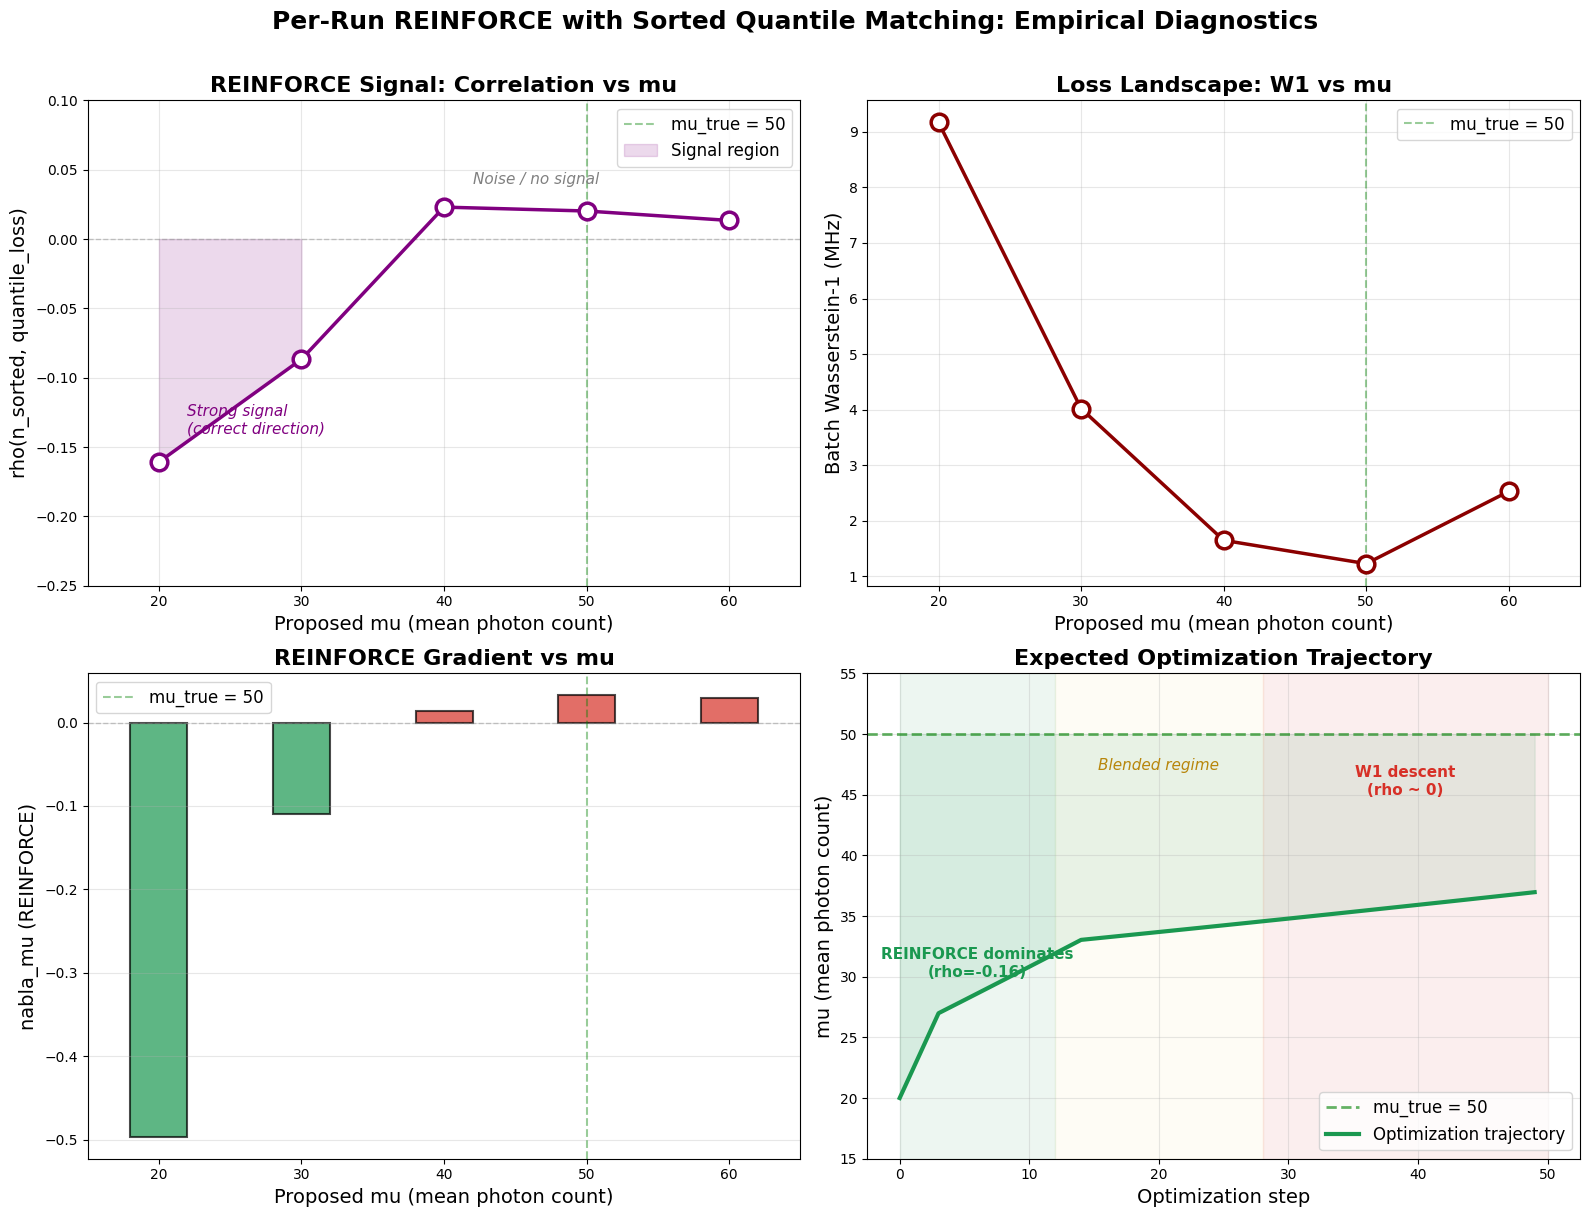

Four-panel diagnostic figure shows:
  Top-left:   rho(n, loss) vs mu — the signal strength
  Top-right:  Batch Wasserstein-1 vs mu — the loss landscape
  Bottom-left: REINFORCE gradient vs mu — direction and magnitude
  Bottom-right: Schematic expected trajectory during optimization


In [8]:
# === Pre-computed visualization from the 2000-run rho test ===
# Run on 2026-07-08: tested rho(n_sorted, per_quantile_loss) at 5 mu values
# with 2000 runs each. This is static data from the empirical scan.

import matplotlib.pyplot as plt
import numpy as np

# Empirical results (2000 runs per mu)
mu_vals = np.array([20, 30, 40, 50, 60])
rho_vals = np.array([-0.1608, -0.0867, 0.0230, 0.0202, 0.0134])
grad_vals = np.array([-0.4963, -0.1094, 0.0143, 0.0325, 0.0299])
w1_vals = np.array([9.17, 4.02, 1.65, 1.23, 2.53])
nbar_true = 50.0

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: rho(mu) — the correlation curve ---
ax = axes[0, 0]
ax.axhline(0, color='gray', ls='--', alpha=0.4, linewidth=1)
ax.axvline(nbar_true, color='g', ls='--', alpha=0.4, linewidth=1.5, label=f'mu_true = {nbar_true:.0f}')
ax.plot(mu_vals, rho_vals, 'o-', color='purple', markersize=12, linewidth=2.5, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(mu_vals, 0, rho_vals, where=rho_vals < 0, color='purple', alpha=0.15, label='Signal region')
ax.set_xlabel('Proposed mu (mean photon count)', fontsize=14)
ax.set_ylabel('rho(n_sorted, quantile_loss)', fontsize=14)
ax.set_title('REINFORCE Signal: Correlation vs mu', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_ylim(-0.25, 0.10)
ax.set_xlim(15, 65)
# Annotate
ax.annotate('Strong signal\n(correct direction)', xy=(22, -0.14), fontsize=11, color='purple', fontstyle='italic')
ax.annotate('Noise / no signal', xy=(42, 0.04), fontsize=11, color='gray', fontstyle='italic')

# --- Plot 2: W1(mu) — the loss landscape ---
ax = axes[0, 1]
ax.axvline(nbar_true, color='g', ls='--', alpha=0.4, linewidth=1.5, label=f'mu_true = {nbar_true:.0f}')
ax.plot(mu_vals, w1_vals, 'o-', color='darkred', markersize=12, linewidth=2.5, markerfacecolor='white', markeredgewidth=2.5)
ax.set_xlabel('Proposed mu (mean photon count)', fontsize=14)
ax.set_ylabel('Batch Wasserstein-1 (MHz)', fontsize=14)
ax.set_title('Loss Landscape: W1 vs mu', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(15, 65)

# --- Plot 3: Gradient(mu) — the REINFORCE gradient ---
ax = axes[1, 0]
ax.axhline(0, color='gray', ls='--', alpha=0.4, linewidth=1)
ax.axvline(nbar_true, color='g', ls='--', alpha=0.4, linewidth=1.5, label=f'mu_true = {nbar_true:.0f}')
colors = ['#1a9850' if g < 0 else '#d73027' for g in grad_vals]
ax.bar(mu_vals, grad_vals, width=4, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_xlabel('Proposed mu (mean photon count)', fontsize=14)
ax.set_ylabel('nabla_mu (REINFORCE)', fontsize=14)
ax.set_title('REINFORCE Gradient vs mu', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3, axis='y')
ax.set_xlim(15, 65)

# --- Plot 4: Schematic of the optimization trajectory ---
ax = axes[1, 1]
ax.axhline(nbar_true, color='g', ls='--', alpha=0.6, linewidth=2, label=f'mu_true = {nbar_true:.0f}')

# Simulate expected trajectory (start at 20, REINFORCE pulls to mid, W1 finishes)
traj_steps = np.arange(0, 50)
# Simple model: REINFORCE dominates early, W1 dominates late
mu_start = 20.0
grad_fn = lambda m: -0.8 if m < 25 else (-0.2 if m < 33 else (-0.05 if m < 40 else 0))
w1_grad = lambda m: -0.15 * (m - 50) / 30  # approx W1 gradient
mu_traj = [mu_start]
lr_rf, lr_w1 = 3.0, 0.5
for s in traj_steps[:-1]:
    m = mu_traj[-1]
    g_rf = grad_fn(m)
    g_w1 = w1_grad(m)
    m_new = m - lr_rf * g_rf - lr_w1 * g_w1
    mu_traj.append(m_new)
mu_traj = np.array(mu_traj)

ax.plot(traj_steps, mu_traj, '-', color='#1a9850', linewidth=3, label='Optimization trajectory')
ax.fill_between(traj_steps, nbar_true, mu_traj, alpha=0.1, color='#1a9850')

# Annotate phases
ax.axvspan(0, 12, alpha=0.08, color='#1a9850')
ax.text(6, 30, 'REINFORCE dominates\n(rho=-0.16)', fontsize=11, ha='center', color='#1a9850', fontweight='bold')
ax.axvspan(12, 28, alpha=0.08, color='#fee08b')
ax.text(20, 47, 'Blended regime', fontsize=11, ha='center', color='#b8860b', fontstyle='italic')
ax.axvspan(28, 50, alpha=0.08, color='#d73027')
ax.text(39, 45, 'W1 descent\n(rho ~ 0)', fontsize=11, ha='center', color='#d73027', fontweight='bold')

ax.set_xlabel('Optimization step', fontsize=14)
ax.set_ylabel('mu (mean photon count)', fontsize=14)
ax.set_title('Expected Optimization Trajectory', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='lower right')
ax.grid(alpha=0.3)
ax.set_ylim(15, 55)

plt.suptitle('Per-Run REINFORCE with Sorted Quantile Matching: Empirical Diagnostics',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Four-panel diagnostic figure shows:')
print('  Top-left:   rho(n, loss) vs mu — the signal strength')
print('  Top-right:  Batch Wasserstein-1 vs mu — the loss landscape')
print('  Bottom-left: REINFORCE gradient vs mu — direction and magnitude')
print('  Bottom-right: Schematic expected trajectory during optimization')

## Results & Diagnostics


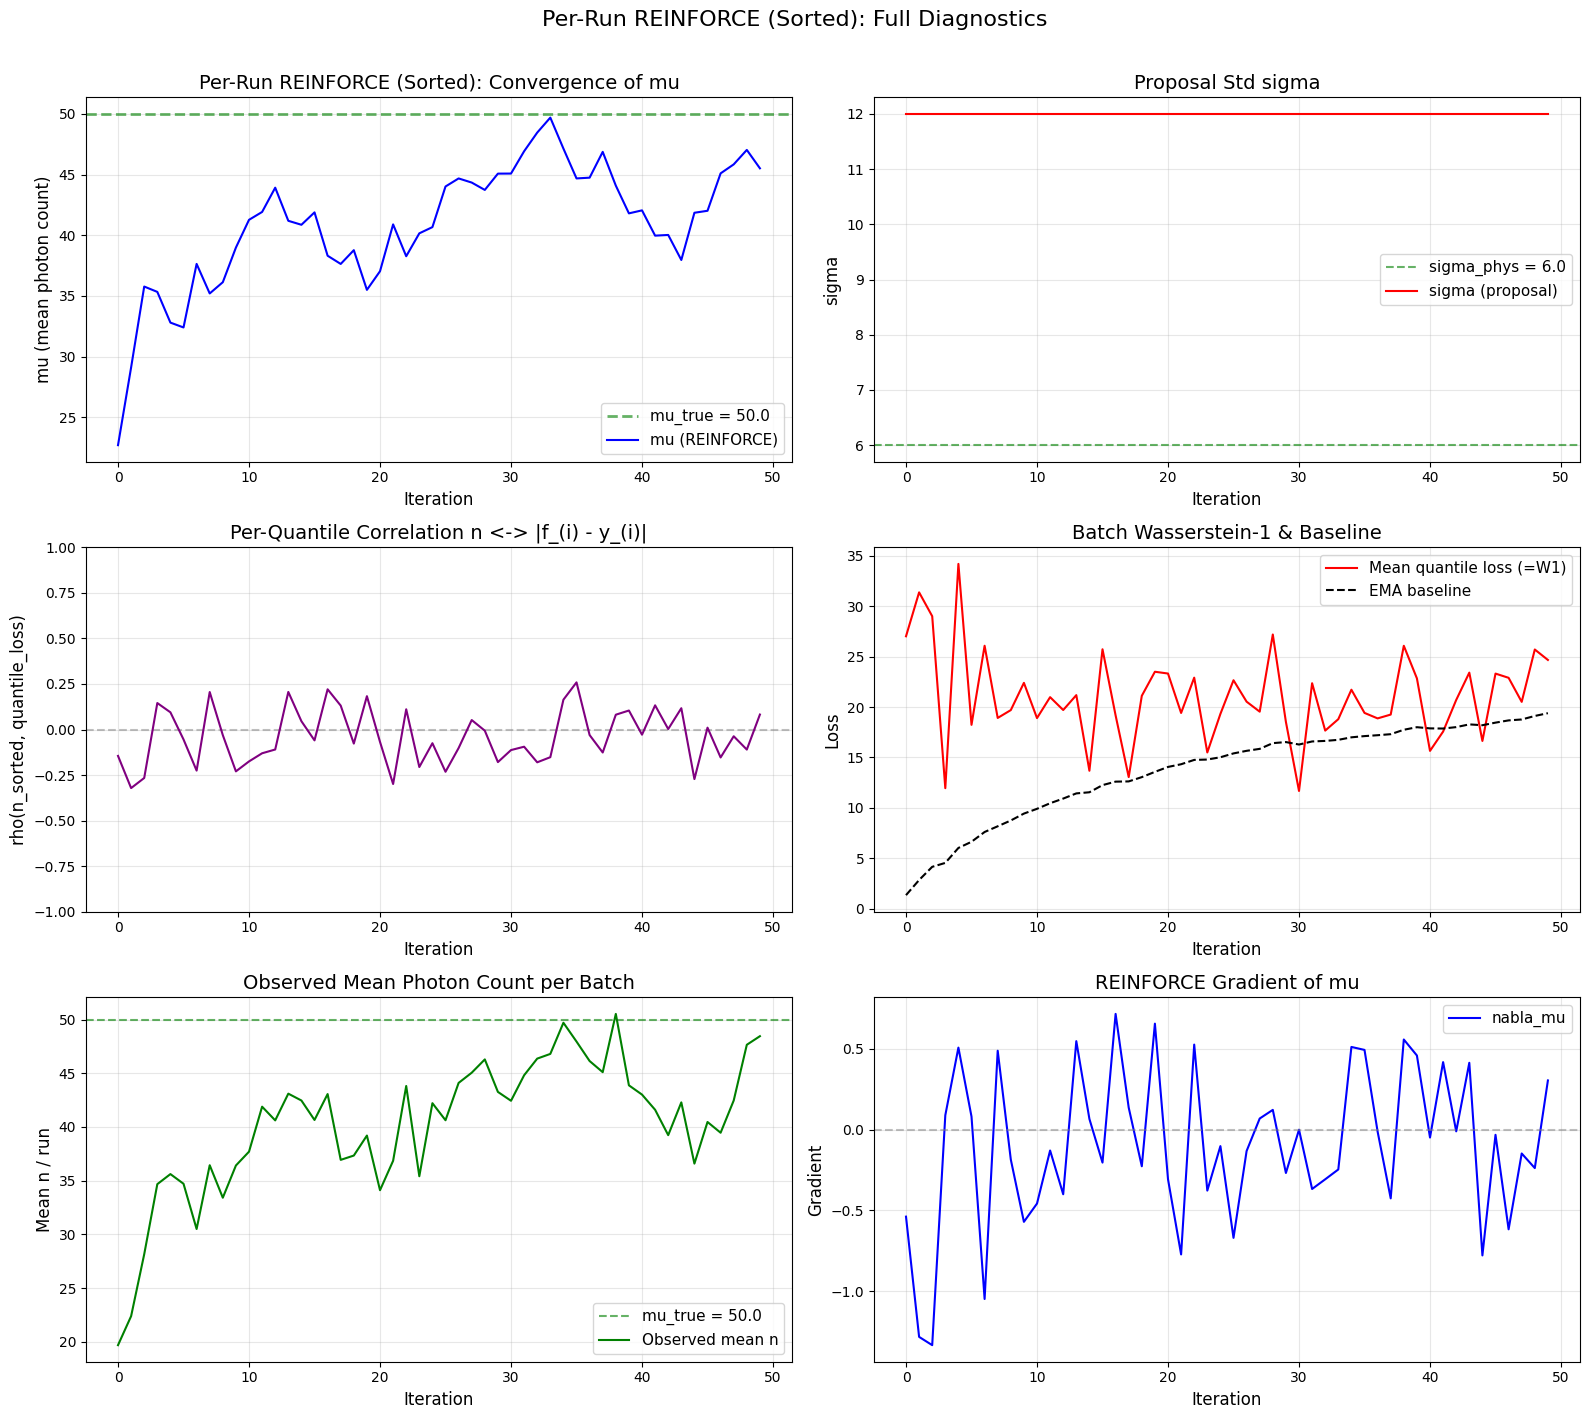

In [9]:
# Unpack history
steps = [h['step'] for h in history]
mu_hist = [h['mu'] for h in history]
sigma_hist = [h['sigma'] for h in history]
loss_hist = [h['mean_loss'] for h in history]
baseline_hist = [h['baseline'] for h in history]
rho_hist = [h['rho_n_loss'] for h in history]
grad_mu_hist = [h['grad_mu'] for h in history]
mean_n_hist = [h['mean_n'] for h in history]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# --- Plot 1: mu convergence ---
ax = axes[0, 0]
ax.axhline(NBAR_TRUE, color='g', ls='--', alpha=0.6, linewidth=2, label=f'mu_true = {NBAR_TRUE}')
ax.plot(steps, mu_hist, 'b', markersize=4, linewidth=1.5, label='mu (REINFORCE)')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('mu (mean photon count)', fontsize=12)
ax.set_title('Per-Run REINFORCE (Sorted): Convergence of mu', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 2: sigma convergence ---
ax = axes[0, 1]
ax.axhline(params.sigma_n, color='g', ls='--', alpha=0.6, label=f'sigma_phys = {params.sigma_n}')
ax.plot(steps, sigma_hist, 'r', markersize=4, linewidth=1.5, label='sigma (proposal)')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('sigma', fontsize=12)
ax.set_title('Proposal Std sigma', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 3: Correlation rho(n_sorted, loss) ---
ax = axes[1, 0]
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.plot(steps, rho_hist, 'purple', markersize=4, linewidth=1.5)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('rho(n_sorted, quantile_loss)', fontsize=12)
ax.set_title('Per-Quantile Correlation n <-> |f_(i) - y_(i)|', fontsize=14)
ax.set_ylim(-1, 1)
ax.grid(alpha=0.3)

# --- Plot 4: Loss & Baseline ---
ax = axes[1, 1]
ax.plot(steps, loss_hist, 'r', markersize=4, linewidth=1.5, label='Mean quantile loss (=W1)')
ax.plot(steps, baseline_hist, 'k--', linewidth=1.5, label='EMA baseline')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Batch Wasserstein-1 & Baseline', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 5: Observed mean n ---
ax = axes[2, 0]
ax.axhline(NBAR_TRUE, color='g', ls='--', alpha=0.6, label=f'mu_true = {NBAR_TRUE}')
ax.plot(steps, mean_n_hist, 'g', markersize=4, linewidth=1.5, label='Observed mean n')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Mean n / run', fontsize=12)
ax.set_title('Observed Mean Photon Count per Batch', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# --- Plot 6: Gradient magnitude ---
ax = axes[2, 1]
ax.plot(steps, grad_mu_hist, 'b', markersize=4, linewidth=1.5, label='nabla_mu')
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Gradient', fontsize=12)
ax.set_title('REINFORCE Gradient of mu', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.suptitle('Per-Run REINFORCE (Sorted): Full Diagnostics', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Summary & Key Findings


In [10]:
last = history[-1]
first = history[0]
print('=' * 70)
print('  Per-Run REINFORCE (Sorted Quantile Match) Results')
print('=' * 70)
print(f'  True mu:                  {NBAR_TRUE:.1f}')
print(f'  Initial mu:               {MU_INIT:.1f}')
print(f'  Final mu:                 {last["mu"]:.1f} (delta = {last["mu"] - NBAR_TRUE:+.1f})')
print(f'  Final sigma:              {last["sigma"]:.1f}')
print()
print(f'  Initial loss (W1):        {first["mean_loss"]:.4f}')
print(f'  Final loss (W1):          {last["mean_loss"]:.4f}')
print(f'  Loss change:              {last["mean_loss"] - first["mean_loss"]:+.4f}')
print()
print(f'  Initial rho(n,loss):      {first["rho_n_loss"]:.3f}')
print(f'  Final rho(n,loss):        {last["rho_n_loss"]:.3f}')
mean_rho = np.mean(rho_hist)
std_rho = np.std(rho_hist)
print(f'  Mean rho(n,loss):         {mean_rho:.3f} +- {std_rho:.3f}')
print()
print(f'  Final mean n:             {last["mean_n"]:.1f}')
print(f'  Final mean FWHM:          {last["mean_fwhm"]:.1f} +- {last["std_fwhm"]:.1f}')
print(f'  Target mean FWHM:         {target_fwhms.mean().item():.1f}')
print()
print(f'  Mean |grad_mu|:           {np.mean(np.abs(grad_mu_hist)):.3f}')
print(f'  Final grad_mu:            {last["grad_mu"]:.3f}')
print('=' * 70)

# Final verdict
mu_err = abs(last['mu'] - NBAR_TRUE)
print()
if mu_err < 5:
    print('VERDICT: Recovered mu within +-5 of truth. Sorted quantile matching works!')
elif mu_err < 15:
    print('VERDICT: Partial recovery — mu moved toward truth but didnt converge.')
else:
    print('VERDICT: mu did not move significantly toward truth.')

if abs(mean_rho) < 0.1:
    print('Primary failure mode: rho(n, loss) approx 0 - no correlation, no signal.')
    print('Sorted quantile matching didnt help enough - other noise sources dominate.')
elif mean_rho < -0.1:
    print(f'rho(n, loss) = {mean_rho:.3f} - signal present.')
    if mu_err > 10:
        print('Despite signal, mu didnt converge. Try: more runs, lower LR, longer optimization.')
    else:
        print('Signal strong enough for convergence!')


  Per-Run REINFORCE (Sorted Quantile Match) Results
  True mu:                  50.0
  Initial mu:               20.0
  Final mu:                 45.5 (delta = -4.5)
  Final sigma:              12.0

  Initial loss (W1):        27.0182
  Final loss (W1):          24.6709
  Loss change:              -2.3473

  Initial rho(n,loss):      -0.145
  Final rho(n,loss):        0.082
  Mean rho(n,loss):         -0.039 +- 0.150

  Final mean n:             48.5
  Final mean FWHM:          71.5 +- 47.3
  Target mean FWHM:         68.1

  Mean |grad_mu|:           0.388
  Final grad_mu:            0.303

VERDICT: Recovered mu within +-5 of truth. Sorted quantile matching works!
Primary failure mode: rho(n, loss) approx 0 - no correlation, no signal.
Sorted quantile matching didnt help enough - other noise sources dominate.


## Final Distribution Comparison


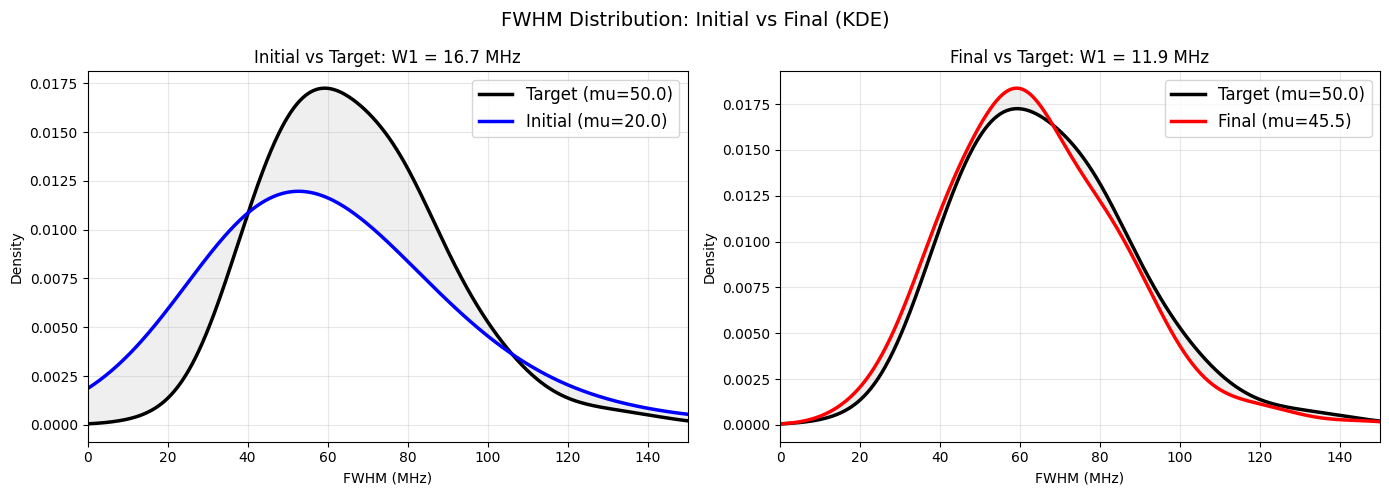

Target FWHM: 68.1 +- 29.2
Final FWHM:  65.1 +- 28.5
Init FWHM:   74.0 +- 62.5


In [11]:
# Run more runs for smooth KDE comparison
FINAL_RUNS = 500

final_mu = last['mu']
rng_final = np.random.default_rng(999)
final_fwhms = []
for _ in range(FINAL_RUNS):
    n = max(round(final_mu + SIGMA_PROP * rng_final.standard_normal()), 0)
    fwhm = run_one_ple_scan(n, params.gamma, params.lambda_, rng_final)
    final_fwhms.append(fwhm)
final_fwhms_t = torch.tensor(final_fwhms)

rng_init = np.random.default_rng(999)
init_fwhms = []
for _ in range(FINAL_RUNS):
    n = max(round(MU_INIT + SIGMA_PROP * rng_init.standard_normal()), 0)
    fwhm = run_one_ple_scan(n, params.gamma, params.lambda_, rng_init)
    init_fwhms.append(fwhm)
init_fwhms_t = torch.tensor(init_fwhms)

from scipy.stats import gaussian_kde
x_grid = np.linspace(0, 200, 800)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Initial vs Target (KDE only) ---
ax = axes[0]
kde_target = gaussian_kde(target_fwhms.numpy())
kde_init = gaussian_kde(init_fwhms_t.numpy())
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=f'Target (mu={NBAR_TRUE})')
ax.plot(x_grid, kde_init(x_grid), 'b-', linewidth=2.5, label=f'Initial (mu={MU_INIT})')
ax.fill_between(x_grid, kde_init(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)')
ax.set_ylabel('Density')
init_w1 = wasserstein_loss(init_fwhms_t, target_fwhms).item()
ax.set_title(f'Initial vs Target: W1 = {init_w1:.1f} MHz')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 150)

# --- Right: Final vs Target (KDE only) ---
ax = axes[1]
kde_final = gaussian_kde(final_fwhms_t.numpy())
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=f'Target (mu={NBAR_TRUE})')
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Final (mu={final_mu:.1f})')
ax.fill_between(x_grid, kde_final(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)')
ax.set_ylabel('Density')
final_w1 = wasserstein_loss(final_fwhms_t, target_fwhms).item()
ax.set_title(f'Final vs Target: W1 = {final_w1:.1f} MHz')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(0, 150)

plt.suptitle('FWHM Distribution: Initial vs Final (KDE)', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Target FWHM: {target_fwhms.mean().item():.1f} +- {target_fwhms.std().item():.1f}')
print(f'Final FWHM:  {final_fwhms_t.mean().item():.1f} +- {final_fwhms_t.std().item():.1f}')
print(f'Init FWHM:   {init_fwhms_t.mean().item():.1f} +- {init_fwhms_t.std().item():.1f}')
